# **1° TASK**

In [3]:

import pandas as pd
import numpy as np

dados = pd.read_csv("/content/tarefa.csv")

nitrogenio = dados["nitrogenio"].dropna()
fosforo = dados["fosforo"].dropna()
potassio = dados["potassio"].dropna()

mediaN = np.mean(nitrogenio)
mediaF = np.mean(fosforo)
mediaP = np.mean(potassio)

dadosNumericos = np.array([nitrogenio,fosforo,potassio])
print(dadosNumericos)
print(dados)


[[42. 35. 50. 39. 22. 47. 31. 40. 25. 53. 36. 18. 55. 33.]
 [21. 25. 18. 12. 23. 15. 20. 14. 26. 17. 22. 10. 28. 16.]
 [35. 28. 40. 33. 20. 38. 26. 34. 22. 42. 30. 36. 17. 45.]]
   id_talhao  temperatura  humidade_solo  ph_solo  nitrogenio  fosforo  \
0      T_101         28.4           45.2      6.2        42.0     21.0   
1      T_102         31.1           38.0      5.5        35.0      NaN   
2      T_103         29.5           50.1      6.8        50.0     25.0   
3      T_104         26.1           42.3      NaN        39.0     18.0   
4      T_105         33.4           31.5      5.1        22.0     12.0   
5      T_106         27.8           48.9      6.4        47.0     23.0   
6      T_107         29.2           36.7      5.8        31.0     15.0   
7      T_108         30.5            NaN      6.1        40.0     20.0   
8      T_109         32.0           33.2      5.3        25.0     14.0   
9      T_110         26.9           52.4      6.7        53.0     26.0   
10     T

# **2° TASK**

In [4]:
dados.describe()
dados.info()
dadosLimpos = dados.copy()

temperatura = dados["temperatura"].fillna(dados["temperatura"].mean())
humidade = dados["humidade_solo"].fillna(dados["humidade_solo"].mean())
ph = dados["ph_solo"].fillna(dados["ph_solo"].mean())
nitrogenio = dados["nitrogenio"].fillna(dados["nitrogenio"].mean())
fosforo = dados["fosforo"].fillna(dados["fosforo"].mean())
potassio = dados["potassio"].fillna(dados["potassio"].mean())

dadosLimpos["temperatura"] = temperatura
dadosLimpos["humidade_solo"] = humidade
dadosLimpos["ph_solo"] = ph
dadosLimpos["nitrogenio"] = nitrogenio
dadosLimpos["fosforo"] = fosforo
dadosLimpos["potassio"] = potassio

dadosLimpos["indiceEstresseTermico"] = (dadosLimpos["temperatura"] *1.2) - (dadosLimpos["humidade_solo"] * 0.5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_talhao                15 non-null     object 
 1   temperatura              15 non-null     float64
 2   humidade_solo            14 non-null     float64
 3   ph_solo                  14 non-null     float64
 4   nitrogenio               14 non-null     float64
 5   fosforo                  14 non-null     float64
 6   potassio                 14 non-null     float64
 7   tipo_historico_colheita  15 non-null     object 
 8   necessita_intervencao    15 non-null     object 
dtypes: float64(6), object(3)
memory usage: 1.2+ KB


# **TASK 3**

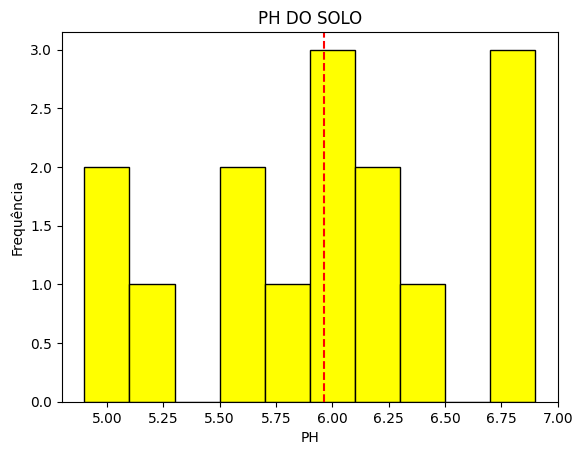

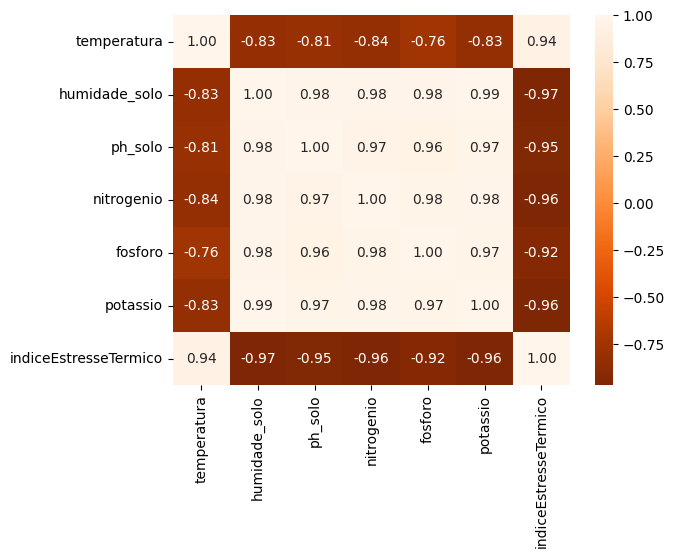

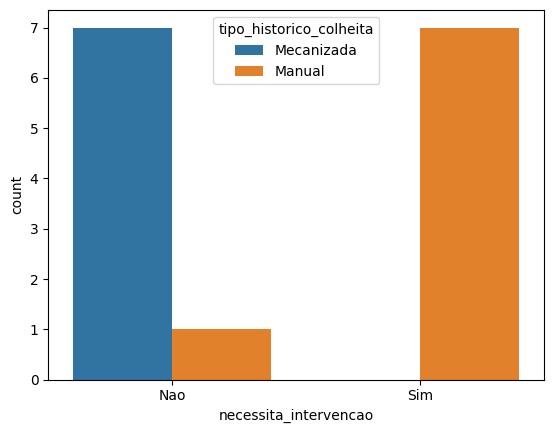

In [5]:
from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt
import seaborn as sns

plt.hist(dadosLimpos['ph_solo'], color = 'yellow', edgecolor = 'black')
plt.title("PH DO SOLO")
plt.xlabel('PH')
plt.ylabel('Frequência')
plt.axvline(dadosLimpos['ph_solo'].mean(), color='red', linestyle = '--')
plt.show()

matCorr = dadosLimpos.drop(columns=["id_talhao", "tipo_historico_colheita", "necessita_intervencao"]).corr()
sns.heatmap(matCorr, annot = True, fmt = ".2f", cmap = 'Oranges_r')
plt.show()

sns.countplot(data = dadosLimpos, x = 'necessita_intervencao', hue = 'tipo_historico_colheita')
plt.show()


# **Task 4**

In [11]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


x = dadosLimpos.drop(columns=['id_talhao',"necessita_intervencao"])
y = dadosLimpos['necessita_intervencao']

le = LabelEncoder()

x['tipo_historico_colheita'] = le.fit_transform(x['tipo_historico_colheita'])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

logReg = LogisticRegression(max_iter = 300)
logReg.fit(x_train, y_train)
logPredict = logReg.predict(x_test)
print("Acurácia: ", accuracy_score(y_test, logPredict))

tree = DecisionTreeClassifier()
tree.fit(x_train,y_train)
treePredict = tree.predict(x_test)
print("Acurácia: ", accuracy_score(y_test, treePredict))

x.head()

Acurácia:  1.0
Acurácia:  1.0


,temperatura,humidade_solo,ph_solo,nitrogenio,fosforo,potassio,tipo_historico_colheita,indiceEstresseTermico
0,28.4,45.2,6.200000,42.0,21.000000,35.0,1,11.48
1,31.1,38.0,5.500000,35.0,19.071429,28.0,0,18.32
2,29.5,50.1,6.800000,50.0,25.000000,40.0,1,10.35
3,26.1,42.3,5.964286,39.0,18.000000,33.0,0,10.17
4,33.4,31.5,5.100000,22.0,12.000000,20.0,0,24.33
